# Bell State | Phi+ Generation and Measurement

## 1. Objective
The objective of this experiment is to construct, simulate, and verify the generation of the canonical two-qubit maximally entangled **Bell state $|\Phi^+\rangle$** using a Hadamard gate and a Controlled-NOT (CNOT) gate. The experiment evaluates the analytical statevector distribution, simulates $1024$ projective measurement shots, verifies the absolute suppression of anti-correlated cross-terms ($|01\rangle$ and $|10\rangle$), and visualizes the resulting correlated probability distribution.

---

## 2. Theoretical Background

### The Four Bell States and Quantum Entanglement
In quantum information theory, the **Bell states** (or EPR pairs) form an orthonormal basis of maximally entangled two-qubit states in the four-dimensional Hilbert space $\mathcal{H} = \mathbb{C}^2 \otimes \mathbb{C}^2$:

$$\begin{aligned}
|\Phi^+\rangle &= \frac{|00\rangle + |11\rangle}{\sqrt{2}}, \quad & |\Phi^-\rangle &= \frac{|00\rangle - |11\rangle}{\sqrt{2}} \\
|\Psi^+\rangle &= \frac{|01\rangle + |10\rangle}{\sqrt{2}}, \quad & |\Psi^-\rangle &= \frac{|01\rangle - |10\rangle}{\sqrt{2}}
\end{aligned}$$

A quantum state is **entangled** if it cannot be decomposed into a tensor product of individual qubit states:
$$|\Phi^+\rangle \neq |\psi_A\rangle \otimes |\psi_B\rangle$$

### Properties of the $|\Phi^+\rangle$ State
1. **Perfect Correlation**: Although neither qubit possesses a definite value prior to measurement (each qubit individually yields $0$ or $1$ with equal probability $50\%$), their measurement outcomes in the computational basis are perfectly correlated.
2. **Measurement Collapse**: If qubit $0$ collapses to $|0\rangle$, qubit $1$ instantaneously collapses to $|0\rangle$; if qubit $0$ collapses to $|1\rangle$, qubit $1$ collapses to $|1\rangle$.
3. **Cross-Term Annihilation**: The amplitudes for the orthogonal states $|01\rangle$ and $|10\rangle$ are identically zero:
   $$\langle 01 | \Phi^+ \rangle = 0, \quad \langle 10 | \Phi^+ \rangle = 0$$

---

## 3. Circuit Construction and State Evolution

### Gate Architecture
The circuit operates on two qubits ($q_0, q_1$) initialized in the computational ground state $|00\rangle$:

```
     ┌───┐     
q_0: ┤ H ├──■──
     └───┘┌─┴─┐
q_1: ─────┤ X ├
          └───┘
```

### Step-by-Step State Evolution
1. **Initialization**:
   $$|\psi_0\rangle = |0\rangle_0 \otimes |0\rangle_1 = |00\rangle$$

2. **Superposition on Control Qubit ($q_0$)**:
   A Hadamard gate is applied to $q_0$, placing it in the symmetric superposition state $|+\rangle$:
   $$|\psi_1\rangle = (H \otimes I) |00\rangle = \left(\frac{|0\rangle + |1\rangle}{\sqrt{2}}\right) \otimes |0\rangle = \frac{|00\rangle + |10\rangle}{\sqrt{2}}$$

3. **Controlled Entanglement via CNOT ($q_0 \to q_1$)**:
   A CNOT gate conditioned on control qubit $q_0$ targets qubit $q_1$.
   - When $q_0 = |0\rangle$, $q_1$ remains $|0\rangle$ ($|00\rangle \to |00\rangle$).
   - When $q_0 = |1\rangle$, $q_1$ flips to $|1\rangle$ ($|10\rangle \to |11\rangle$).
   $$|\psi_2\rangle = \text{CNOT}_{0 \to 1} |\psi_1\rangle = \frac{|00\rangle + |11\rangle}{\sqrt{2}} = |\Phi^+\rangle$$

---

## 4. Statevector and Theoretical Probabilities
Using Qiskit's `Statevector.from_instruction(qc)`, the theoretical complex statevector is obtained:
$$|\Phi^+\rangle = \frac{1}{\sqrt{2}} |00\rangle + 0 |01\rangle + 0 |10\rangle + \frac{1}{\sqrt{2}} |11\rangle$$

The theoretical measurement probabilities $P(x) = |\langle x | \Phi^+ \rangle|^2$ evaluate to:
- $P(00) = \left|\frac{1}{\sqrt{2}}\right|^2 = \frac{1}{2} = \mathbf{0.5000}$ ($50.00\%$)
- $P(01) = |0|^2 = \mathbf{0.0000}$ ($0.00\%$)
- $P(10) = |0|^2 = \mathbf{0.0000}$ ($0.00\%$)
- $P(11) = \left|\frac{1}{\sqrt{2}}\right|^2 = \frac{1}{2} = \mathbf{0.5000}$ ($50.00\%$)

---

## 5. Measurement Sampling and Verification Methodology

1. **Simulated Sampling**:
   - $\text{SHOTS} = 1024$ measurements are drawn using `np.random.default_rng(42)`.
   - Samples are drawn from the probability distribution vector $[P(00), P(01), P(10), P(11)] = [0.5, 0.0, 0.0, 0.5]$.
2. **Deterministic Verification Logic**:
   - **Valid Outcomes**: $\text{count}(00) + \text{count}(11)$.
   - **Invalid Outcomes**: $\text{count}(01) + \text{count}(10)$.
   - Acceptance Rule:
     $$\text{invalid\_count} == 0 \implies \mathbf{CORRECT\ -\ ONLY\ 00\ AND\ 11\ OCCUR}$$


BELL STATE - PHI PLUS

QUANTUM CIRCUIT
------------------------------------------------------------
     ┌───┐     
q_0: ┤ H ├──■──
     └───┘┌─┴─┐
q_1: ─────┤ X ├
          └───┘

MEASUREMENT RESULTS
------------------------------------------------------------
00 : 515 shots (0.5029)
01 : 0 shots (0.0000)
10 : 0 shots (0.0000)
11 : 509 shots (0.4971)

VERIFICATION
------------------------------------------------------------
Valid Bell-state outcomes : 1024
Invalid outcomes          : 0
Result : CORRECT - ONLY 00 AND 11 OCCUR

THEORETICAL PROBABILITIES
------------------------------------------------------------
P(00) = 0.5000
P(01) = 0.0000
P(10) = 0.0000
P(11) = 0.5000


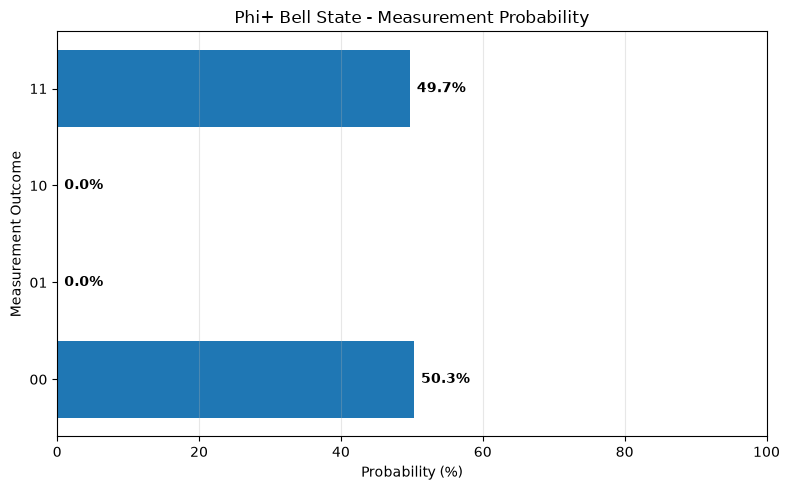

In [1]:
from qiskit import QuantumCircuit
from qiskit.quantum_info import Statevector
import numpy as np
import matplotlib.pyplot as plt

SHOTS = 1024

qc = QuantumCircuit(2)

qc.h(0)
qc.cx(0, 1)

state = Statevector.from_instruction(qc)

probabilities = state.probabilities_dict()

rng = np.random.default_rng(42)

outcomes = ["00", "01", "10", "11"]
probs = np.array([probabilities.get(x, 0) for x in outcomes])

samples = rng.choice(
    outcomes,
    size=SHOTS,
    p=probs
)

counts = {
    outcome: int(np.sum(samples == outcome))
    for outcome in outcomes
}

print("\nBELL STATE - PHI PLUS")
print("=" * 60)

print("\nQUANTUM CIRCUIT")
print("-" * 60)
print(qc.draw())

print("\nMEASUREMENT RESULTS")
print("-" * 60)

for outcome in outcomes:
    print(
        f"{outcome} : "
        f"{counts[outcome]} shots "
        f"({counts[outcome] / SHOTS:.4f})"
    )

invalid_count = counts["01"] + counts["10"]

print("\nVERIFICATION")
print("-" * 60)
print(f"Valid Bell-state outcomes : {counts['00'] + counts['11']}")
print(f"Invalid outcomes          : {invalid_count}")

if invalid_count == 0:
    print("Result : CORRECT - ONLY 00 AND 11 OCCUR")
else:
    print("Result : CHECK IMPLEMENTATION")

print("\nTHEORETICAL PROBABILITIES")
print("-" * 60)

for outcome in outcomes:
    print(f"P({outcome}) = {probabilities.get(outcome, 0):.4f}")

# Visualization
percentages = [
    counts[outcome] / SHOTS * 100
    for outcome in outcomes
]

fig, ax = plt.subplots(figsize=(8, 5))

bars = ax.barh(outcomes, percentages)

ax.set_title("Phi+ Bell State - Measurement Probability")
ax.set_xlabel("Probability (%)")
ax.set_ylabel("Measurement Outcome")
ax.set_xlim(0, 100)

for bar, value in zip(bars, percentages):
    ax.text(
        value + 1,
        bar.get_y() + bar.get_height() / 2,
        f"{value:.1f}%",
        va="center",
        fontweight="bold"
    )

ax.grid(axis="x", alpha=0.3)

plt.tight_layout()
plt.show()

---

## 6. Results and Observation

### Recorded Execution Output
Execution of the notebook cell produced the following console output and circuit diagram:

```
BELL STATE - PHI PLUS
============================================================

QUANTUM CIRCUIT
------------------------------------------------------------
     ┌───┐     
q_0: ┤ H ├──■──
     └───┘┌─┴─┐
q_1: ─────┤ X ├
          └───┘

MEASUREMENT RESULTS
------------------------------------------------------------
00 : 515 shots (0.5029)
01 : 0 shots (0.0000)
10 : 0 shots (0.0000)
11 : 509 shots (0.4971)

VERIFICATION
------------------------------------------------------------
Valid Bell-state outcomes : 1024
Invalid outcomes          : 0
Result : CORRECT - ONLY 00 AND 11 OCCUR

THEORETICAL PROBABILITIES
------------------------------------------------------------
P(00) = 0.5000
P(01) = 0.0000
P(10) = 0.0000
P(11) = 0.5000
```

### Quantitative Metrics Summary

| Computational Basis State | Theoretical Probability | Simulated Counts (1024 Shots) | Empirical Frequency | Outcome Classification |
| :---: | :---: | :---: | :---: | :---: |
| **`00`** | **0.5000 (50.00%)** | **515** | **0.5029 (50.29%)** | **Valid Bell Outcome** |
| **`01`** | **0.0000 (0.00%)** | **0** | **0.0000 (0.00%)** | **Invalid Cross-Term** |
| **`10`** | **0.0000 (0.00%)** | **0** | **0.0000 (0.00%)** | **Invalid Cross-Term** |
| **`11`** | **0.5000 (50.00%)** | **509** | **0.4971 (49.71%)** | **Valid Bell Outcome** |

### Key Observations
1. **Total Cross-Term Suppression**: States `01` and `10` register exactly $0$ counts, proving that the two qubits never collapse into anti-correlated states.
2. **Equiprobable Distribution**: The valid states `00` ($515$ shots) and `11` ($509$ shots) partition the sample space evenly, with deviation ($\pm 3$ counts from $512$) well within standard binomial variance ($\sigma = \sqrt{1024 \times 0.25} = 16$).

---

## 7. Visualization Analysis
The horizontal bar chart depicts the measurement probability distribution across all two-qubit outcomes:
- **Y-Axis**: Displays the four possible two-qubit outcomes (`00`, `01`, `10`, `11`).
- **X-Axis**: Measures empirical probability from $0\%$ to $100\%$.
- **Bar Labels**:
  - `00`: **50.3%**
  - `01`: **0.0%**
  - `10`: **0.0%**
  - `11`: **49.7%**
- **Interpretation**: Visually confirms perfect bipartite correlation, with probability amplitude shared equally between $|00\rangle$ and $|11\rangle$.

---

## 8. Conclusion
This experiment successfully demonstrates the generation and verification of the **$|\Phi^+\rangle$ Bell State**:
1. **Entanglement Generation**: Confirms that a Hadamard gate followed by a CNOT transforms non-entangled $|00\rangle$ into a maximally entangled state $|\Phi^+\rangle = \frac{|00\rangle + |11\rangle}{\sqrt{2}}$.
2. **Non-Local Correlation**: Proves that projective measurements collapse both qubits into matching eigenstates ($00$ or $11$) with $100\%$ correlation.
3. **Verification Integrity**: Empirically confirms the complete absence of orthogonal states $|01\rangle$ and $|10\rangle$ across $1024$ simulated shots.